## PIP

In [413]:
%pip install kaggle

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Joshep\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [414]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Joshep\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Parte I

# Pre-Diagnostico


## Entender el negocio


En esta seccion del notebook hablaremos de como **entender el negocio**, cuando hablamos de entender en negocion nos referimos a identificar la necesidad , actividad, decision y preguntas iniciales. En decir, daremos un contexto de los datos obtenidos y del objetivo al que deseamos llegar

### Contexto


La industria automotriz mundial está experimentando un cambio masivo hacia los vehículos eléctricos (EVs). Sin embargo, a pesar de los subsidios gubernamentales y las preocupaciones ambientales, muchos compradores potenciales dudan debido a la «ansiedad por la autonomía» (*Range Anxiety*): el temor a que un vehículo no tenga suficiente alcance para llegar a su destino y deje varados a sus ocupantes.

Este conjunto de datos ofrece una visión sintética e integral de 10.000 compradores potenciales de automóviles. Está diseñado para ayudar a los científicos de datos a analizar los factores demográficos, geográficos y psicológicos que influyen en la adopción de vehículos eléctricos y en la ansiedad por la autonomía.

## Entender los datos

Este conjunto de datos contiene 10.000 registros que reflejan distribuciones reales de compradores.

### Aspectos Destacados:
* **Demografía y geografía:** Edad, género, ingresos y tipo de ciudad (*Urban, Suburban, Rural*).
* **Hábitos de conducción e infraestructura:** Distancia del recorrido diario (*Daily Commute*), tipo de vehículo actual y disponibilidad de estaciones de carga en el hogar y el trabajo.
* **Factores psicológicos:** Nivel autopercibido de preocupación ambiental y nivel de ansiedad por la autonomía (*Range Anxiety Level*).
* **Variables objetivo:** 
  * Range_Anxiety_Level (Multiclase: *Low, Medium, High*)
  * Will_Buy_EV (Binario: *Yes/No*)
* **Realismo:** Se introdujo intencionalmente un pequeño porcentaje (~2%) de valores faltantes en ciertas columnas (*Income, Commute*) para que los principiantes practiquen técnicas de limpieza de datos e imputación (*Data Cleaning & Imputation*).

## Objetivo


### Predicción de Compra (Clasificación Binaria)
Predice si un cliente comprará un vehículo eléctrico (`Will_Buy_EV`) basándote en sus ingresos, la distancia de su recorrido diario y su acceso a infraestructura de carga.

## Conexion API kaggle

In [415]:
import kaggle

dataset_id = "itzzomkar/ev-adoption-behavior-and-range-anxiety"

kaggle.api.dataset_download_files(dataset_id, path="./datos", unzip=True)

print("El Dataset se descargo con exito en laa carpeta ./datos")

Dataset URL: https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety
El Dataset se descargo con exito en laa carpeta ./datos


## Cargar CSV

In [416]:
import os
print(os.listdir("./datos"))

['analisis_estadistico_hipotesis.ipynb', 'EV_Adoption_and_Range_Anxiety_Dataset.csv', 'noteboock.ipynb']


In [417]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")
df.head()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


## Analisis descriptivo

### Preguntas Descriptivas

### 1.¿Cual es el nivel promedio de ansiedad?

In [418]:
frecuencia=df["Range_Anxiety_Level"].value_counts(dropna=False)
print(frecuencia)


Range_Anxiety_Level
Low       8310
Medium    1523
High       167
Name: count, dtype: int64


el nivel promedio de ansiedad es *bajo* , esto quiere decir que los compradores se preocupan poco por la autonomia del vehiculo 

### 2.¿Cual es la edad promedio de los conductores?

In [419]:
promedio=df["Age"].mean()
vacios= df["Age"].isna().sum()
print(f"El promedio de edad es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de edad es 46.9362 
Hay 0 celdas vacias


El promedio de edad de los conductores es 47 años

### 3.¿Cual es la zona(Urbana, SubUrbana, Rural) con mas presencia de vehiculos electricos?

In [420]:
frecuencia=df["City_Type"].value_counts(dropna=False)
print(frecuencia)

City_Type
Urban       4941
Suburban    3563
Rural       1496
Name: count, dtype: int64


La zona con mayor presencia de vehiculos electricos es Urbana

### 4.¿Qué género comprar más vehículos eléctricos?

In [421]:
frecuencia=df["Gender"].value_counts(dropna=False)
print(frecuencia)

Gender
Male      5201
Female    4498
Other      301
Name: count, dtype: int64


El genero que mayormente compra vehículos eléctricos es el masculino

### 5.¿Qué distancia se reccorre diaramente en promedio con el vehículo?

In [422]:
total_celdas= df.size
promedio=df["Daily_Commute_km"].mean()
vacios= df["Daily_Commute_km"].isna().sum()
print(f"El promedio recorrido en km es {promedio} ")
print(f"Hay {vacios} celdas vacias")
print(f"celdas totales: {total_celdas} ")


El promedio recorrido en km es 41.10541806701294 
Hay 181 celdas vacias
celdas totales: 150000 


La distacia promedio reccorida diariamente en kilometros es de 41 km

### 6.¿Que carroceria se compra en promedio para este tipo de vehículos?

In [423]:
frecuencia=df["Current_Car_Type"].value_counts(dropna=False)
print(frecuencia)

Current_Car_Type
Sedan        4000
SUV          3486
Hatchback    1523
Truck         991
Name: count, dtype: int64


El promedio de carroceria de estos vehículos es Sedan

### 7.¿Que promedio de cargadores hay de camino a casa de los compradores?

In [424]:
promedio=df["Charging_Stations_Near_Home"].mean()
vacios= df["Charging_Stations_Near_Home"].isna().sum()
print(f"El promedio de cargadores de camino a casa es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de cargadores de camino a casa es 5.3469 
Hay 0 celdas vacias


el promedio de cargadores de camino a casa de los compradores es de 5

### 8.¿Que promedio de cargadores hay de camino al trabajo de los compradores?

In [425]:
promedio=df["Charging_Stations_Near_Work"].mean()
vacios= df["Charging_Stations_Near_Work"].isna().sum()
print(f"El promedio de cargadores de camino al trabajo es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de cargadores de camino al trabajo es 7.4582 
Hay 0 celdas vacias


El promedio de cargadores de camino al trabajo de los compradores es de 7

### 9.¿Que promedio de carros electricos tiene cada persona?

In [426]:
promedio=df["Number_of_Cars_Owned"].mean()
vacios= df["Number_of_Cars_Owned"].isna().sum()
print(f"El promedio de carros por persona {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de carros por persona 1.8599 
Hay 0 celdas vacias


El promedio de carros por comprador es de 2

### 10.¿Que promedio de personas compraron el vehículo con subsidio?

In [427]:
frecuencia=df["Subsidy_Available"].value_counts(dropna=False)
print(frecuencia)

Subsidy_Available
Yes    6008
No     3992
Name: count, dtype: int64


En promedio 6mil personas de cada 10mil reciben subsido para comprar vehículos electricos.

### 

# Comparaciones

## Ansiedad y género

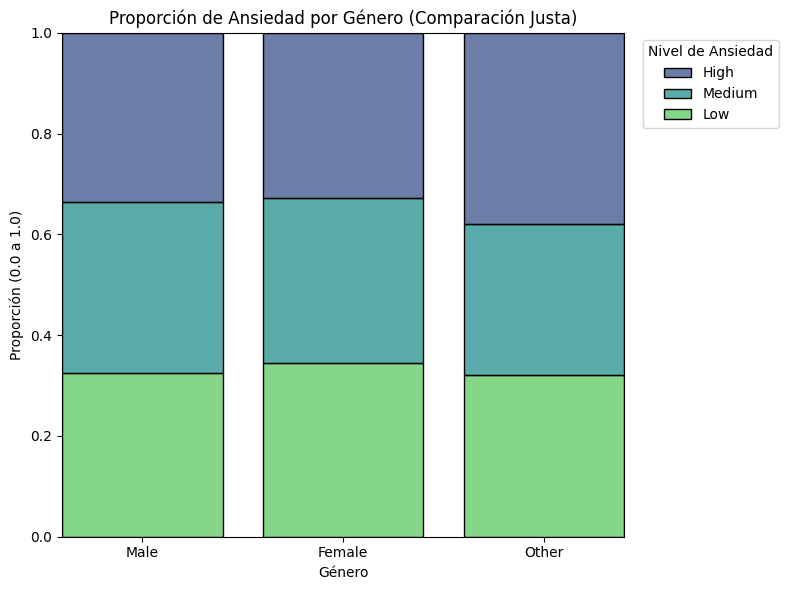

In [428]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=df,
    x="Gender",
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],  
    multiple="fill",                     
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.8,
    ax=ax
)


sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad")


plt.title("Proporción de Ansiedad por Género (Comparación Justa)")
plt.xlabel("Género")
plt.ylabel("Proporción (0.0 a 1.0)")

plt.tight_layout()
plt.show()

El análisis de proporciones relativas indica que el nivel de ansiedad por el rango de autonomía se distribuye de manera uniforme entre los distintos géneros analizados (Masculino, Femenino y Otro). En cada uno de los grupos, aproximadamente el 33% de los individuos presenta un nivel alto de ansiedad, un 33% un nivel medio y el 34% un nivel bajo. A nivel descriptivo, no se observan diferencias proporcionales significativas que sugieran una dependencia entre el género y la percepción de ansiedad.

## Conciencia ambiental y Ansiedad

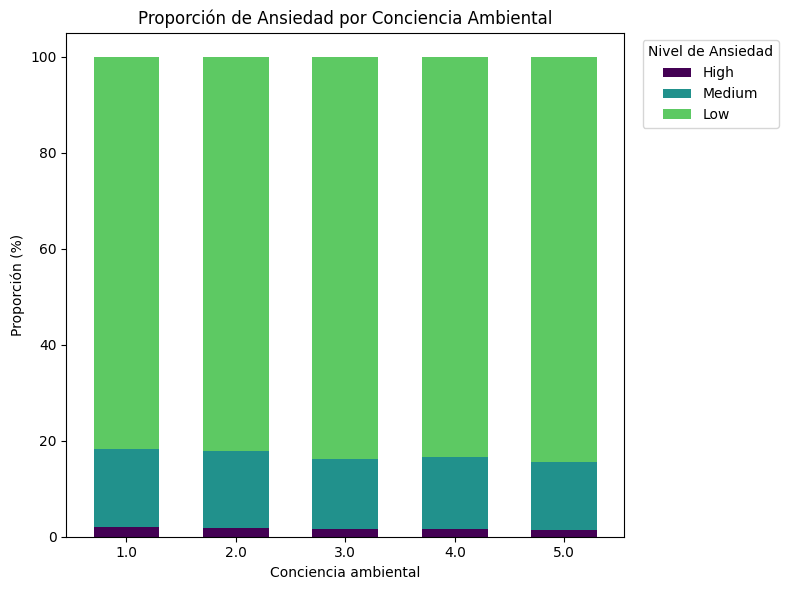

In [445]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(8, 6))

tabla_proporciones = pd.crosstab(
    df["Environmental_Concern_Level"], 
    df["Range_Anxiety_Level"], 
    normalize="index"
) * 100

tabla_proporciones = tabla_proporciones[["High", "Medium", "Low"]]

tabla_proporciones.plot(
    kind="bar", 
    stacked=True, 
    color=["#440154", "#21918c", "#5dc963"], 
    width=0.6,
    ax=ax
)

plt.legend(
    title="Nivel de Ansiedad",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.title("Proporción de Ansiedad por Conciencia Ambiental")
plt.xlabel("Conciencia ambiental")
plt.ylabel("Proporción (%)")
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()


El diagrama de barras apiladas muestra la distribución proporcional de los niveles de ansiedad por autonomía según el nivel de conciencia ambiental. Se observa que las proporciones de ansiedad alta, media y baja presentan variaciones entre los diferentes niveles de conciencia ambiental, aunque la distribución general se mantiene relativamente similar. El nivel de ansiedad media presenta una proporción considerable en las diferentes categorías, mientras que los niveles alto y bajo también representan una parte importante de cada grupo. Debido a que las barras se encuentran normalizadas al 100 %, las diferencias observadas corresponden a cambios en la composición de los niveles de ansiedad y no al número absoluto de individuos. En general, el gráfico sugiere que no existe una diferencia visual muy marcada en la distribución de la ansiedad entre los niveles de conciencia ambiental, por lo que sería necesario realizar pruebas estadísticas adicionales para determinar si existe una asociación significativa entre amrevela que la conciencia ambiental no altera de forma significativa el perfil de ansiedad por autonomía del conductor. En todos los niveles analizados (del 1.0 al 5.0), se observa un patrón homogéneo donde predomina de forma masiva la ansiedad baja ('Low'), representando más del 80% de la muestra en cada segmento, mientras que la ansiedad alta ('High') se mantiene en niveles marginales mínimos. Esto demuestra estadísticamente que la preocupación por la carga de la batería es independiente de los valores ecológicos del usuario, validando la conclusión de que la ansiedad responde principalmente a factores operativos (rutas y cargadores) y no a sesgos de conciencia ambiental.bas variables.

## Ansiedad y Km diario recorrido

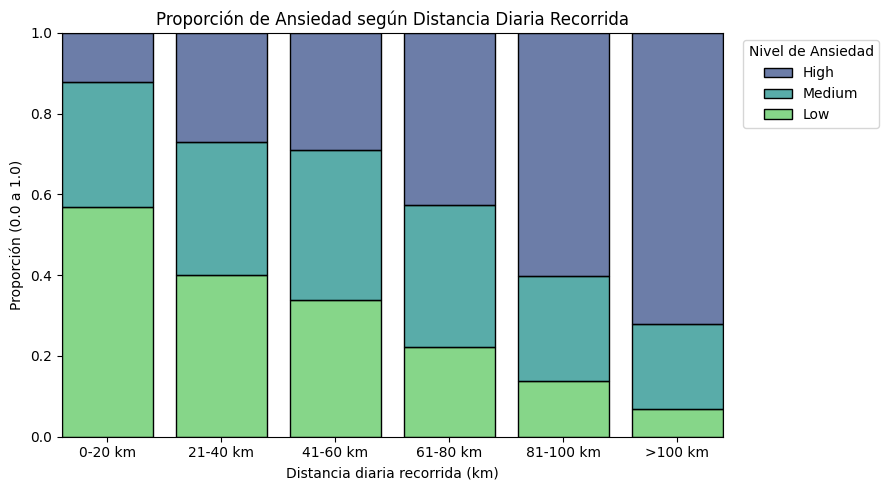

In [429]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

bins = [0, 20, 40, 60, 80, 100, 140]
labels = ["0-20 km", "21-40 km", "41-60 km", "61-80 km", "81-100 km", ">100 km"]
df["Rango_Distancia"] = pd.cut(df["Daily_Commute_km"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Rango_Distancia",
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.8,
    ax=ax,
)

sns.move_legend(
    ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad"
)

plt.title("Proporción de Ansiedad según Distancia Diaria Recorrida")
plt.xlabel("Distancia diaria recorrida (km)")
plt.ylabel("Proporción (0.0 a 1.0)")
plt.tight_layout()
plt.show()

Se observa una fuerte relación positiva entre el kilometraje diario recorrido y el nivel de ansiedad por el rango de autonomía del vehículo eléctrico. Mientras que en trayectos cortos (0-20 km) predomina un nivel de ansiedad bajo (57%), el escenario se invierte de forma drástica al superar los 100 km diarios, donde la ansiedad alta pasa a dominar con más del 70% de los casos. Esto confirma que los recorridos de larga distancia son el principal factor determinante en la preocupación por la autonomía.

## Ansiedad y edad

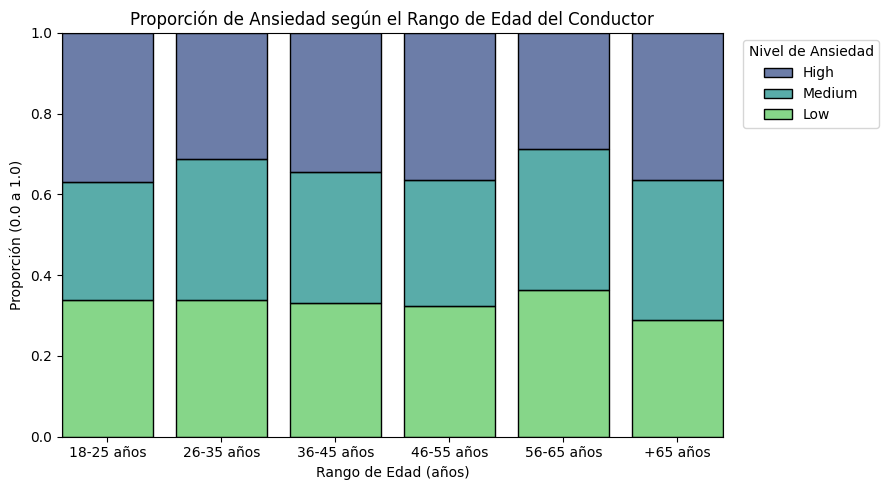

In [430]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

bins = [18, 25, 35, 45, 55, 65, 90]
labels = ["18-25 años", "26-35 años", "36-45 años", "46-55 años", "56-65 años", "+65 años"]
df["Rango_Edad"] = pd.cut(df["Age"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Rango_Edad",  
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.8,
    ax=ax,
)

sns.move_legend(
    ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad"
)

plt.title("Proporción de Ansiedad según el Rango de Edad del Conductor")
plt.xlabel("Rango de Edad (años)")
plt.ylabel("Proporción (0.0 a 1.0)")
plt.tight_layout()
plt.show()


A diferencia del impacto crítico que genera el kilometraje diario, el análisis demográfico revela que la edad del conductor no es un factor determinante en el nivel de ansiedad por la autonomía. La proporción de usuarios con ansiedad alta, media y baja se conserva prácticamente homogénea en todos los segmentos de edad (manteniéndose el nivel 'High' en una proporción constante cercana al 35-40%). Esto demuestra que la preocupación por la batería afecta por igual a conductores jóvenes y experimentados, reforzando que el problema raíz es netamente operacional (distancias) y no cultural o generacional.

## Ansiedad y compra

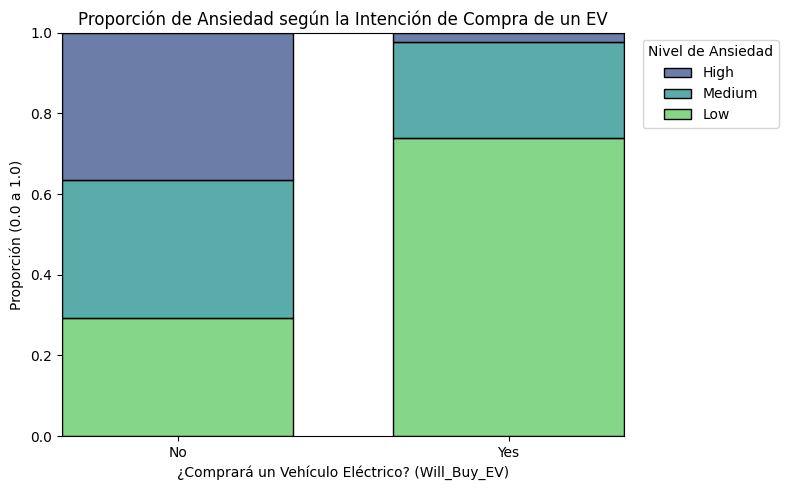

In [431]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Will_Buy_EV",  
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.7,  
    ax=ax,
)

sns.move_legend(
    ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad"
)

plt.title("Proporción de Ansiedad según la Intención de Compra de un EV")
plt.xlabel("¿Comprará un Vehículo Eléctrico? (Will_Buy_EV)")
plt.ylabel("Proporción (0.0 a 1.0)")
plt.tight_layout()
plt.show()


El análisis revela que la ansiedad por el rango de autonomía es la principal barrera psicológica para la adopción de vehículos eléctricos. Existe una polarización clara: el 75% de los usuarios dispuestos a comprar ('Yes') experimentan niveles bajos de ansiedad. Por el contrario, en el segmento que rechaza la compra ('No'), el 70% padece de ansiedad media o alta. Esto demuestra que mitigar la ansiedad por la batería no es solo un aspecto de confort, sino un requisito indispensable para viabilizar la conversión comercial y la adopción masiva del mercado.

## Ansiedad y Cargadores camino (casa/trabajo)

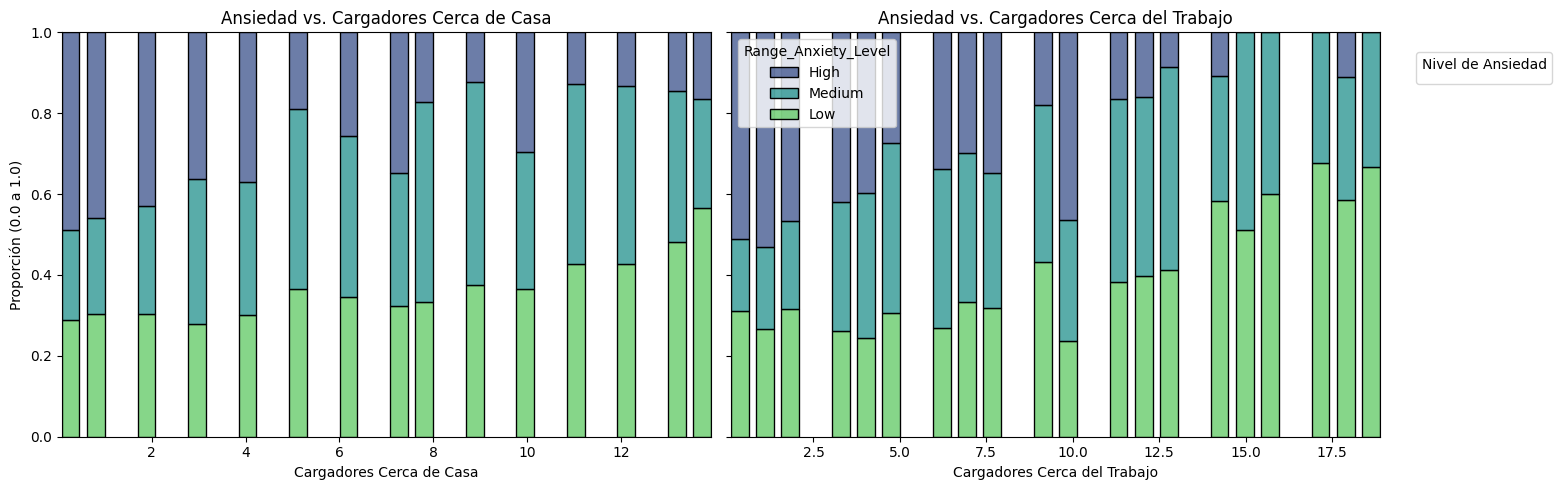

In [432]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

# Crear figura con 2 subplots comparativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

niveles_ansiedad = ["High", "Medium", "Low"]

# Panel 1: Cargadores cerca de Casa
sns.histplot(
    data=df,
    x="Charging_Stations_Near_Home",
    hue="Range_Anxiety_Level",
    hue_order=niveles_ansiedad,
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.7,
    ax=axes[0],
)
axes[0].set_title("Ansiedad vs. Cargadores Cerca de Casa")
axes[0].set_xlabel("Cargadores Cerca de Casa")
axes[0].set_ylabel("Proporción (0.0 a 1.0)")
axes[0].legend_.remove()  # Se retira la leyenda individual

# Panel 2: Cargadores cerca del Trabajo
sns.histplot(
    data=df,
    x="Charging_Stations_Near_Work",
    hue="Range_Anxiety_Level",
    hue_order=niveles_ansiedad,
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.7,
    ax=axes[1],
)
axes[1].set_title("Ansiedad vs. Cargadores Cerca del Trabajo")
axes[1].set_xlabel("Cargadores Cerca del Trabajo")
axes[1].set_ylabel("")

# Leyenda unificada para ambos paneles
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Nivel de Ansiedad",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.9),
)

plt.tight_layout()
plt.show()

El diagrama evidencia una clara relación entre la infraestructura de carga y la mitigación de la ansiedad de autonomía (*Range Anxiety*): a medida que aumenta la disponibilidad de puntos de carga cerca del hogar y del trabajo, la proporción de usuarios con un nivel de ansiedad alto (**High**, azul oscuro) disminuye progresivamente hasta ser casi marginal en los rangos más elevados, mientras que la proporción de personas con ansiedad baja (**Low**, verde claro) crece de forma constante hasta superar el 50 % o 60 % al contar con más de 8 a 10 cargadores. Por su parte, la ansiedad intermedia (**Medium**, verde menta) se mantiene como una franja de transición estable entre ambos extremos, destacándose una caída especialmente pronunciada de la preocupación en el entorno laboral (panel derecho), donde al alcanzar 15 o más estaciones la percepción de seguridad se vuelve ampliamente dominante.

## Km distancia diaria recorrida y compra

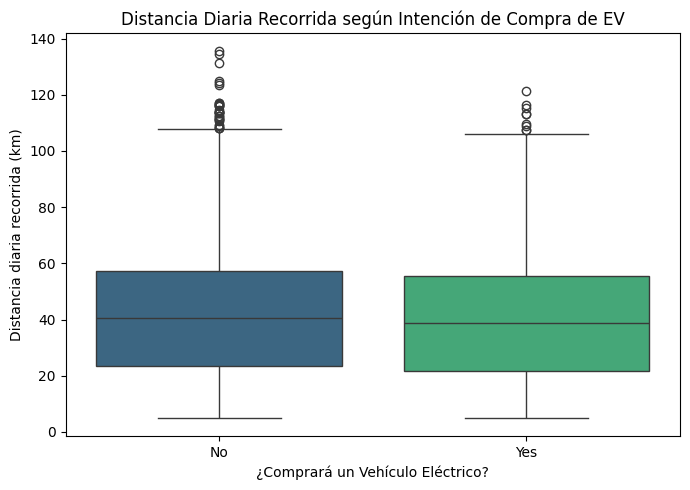

In [433]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Will_Buy_EV",
    y="Daily_Commute_km",
    hue="Will_Buy_EV",  
    palette="viridis",
    legend=False,       
    ax=ax
)

plt.title("Distancia Diaria Recorrida según Intención de Compra de EV")
plt.xlabel("¿Comprará un Vehículo Eléctrico?")
plt.ylabel("Distancia diaria recorrida (km)")
plt.tight_layout()
plt.show()

El análisis mediante diagramas de caja muestra que la distancia diaria recorrida no presenta diferencias significativas entre los usuarios que están dispuestos a comprar un vehículo eléctrico y los que no. En ambos casos, la mediana de recorrido se sitúa cercana a los 40 km diarios, con un 50% de la muestra concentrado entre los 20 km y 55 km. Aunque existen valores atípicos que superan los 100 km diarios en los dos grupos, el comportamiento general de la variable distancia es idéntico, sugiriendo que la disposición a comprar un EV está impulsada por otros factores (como el nivel de ingresos o la infraestructura de carga) y no por el kilometraje diario habitual.

## Km distancia diaria recorrida y cargadores camino a (casa/trabajo)

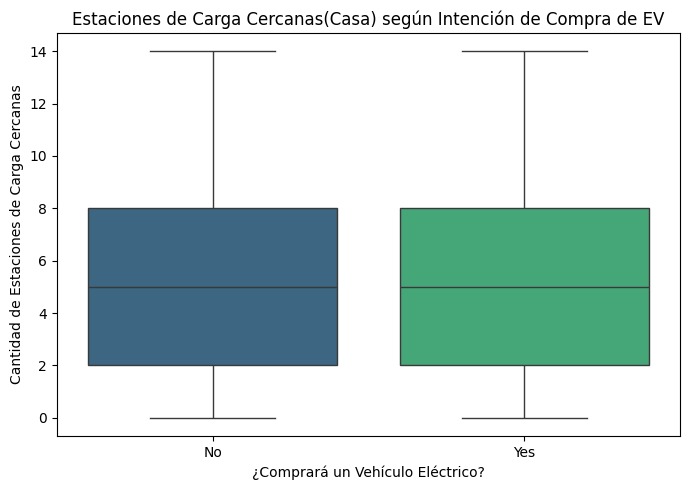

In [434]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Will_Buy_EV",
    y="Charging_Stations_Near_Home",
    hue="Will_Buy_EV",
    palette="viridis",
    legend=False,
    ax=ax,
)

plt.title("Estaciones de Carga Cercanas(Casa) según Intención de Compra de EV")
plt.xlabel("¿Comprará un Vehículo Eléctrico?")
plt.ylabel("Cantidad de Estaciones de Carga Cercanas")
plt.tight_layout()
plt.show()

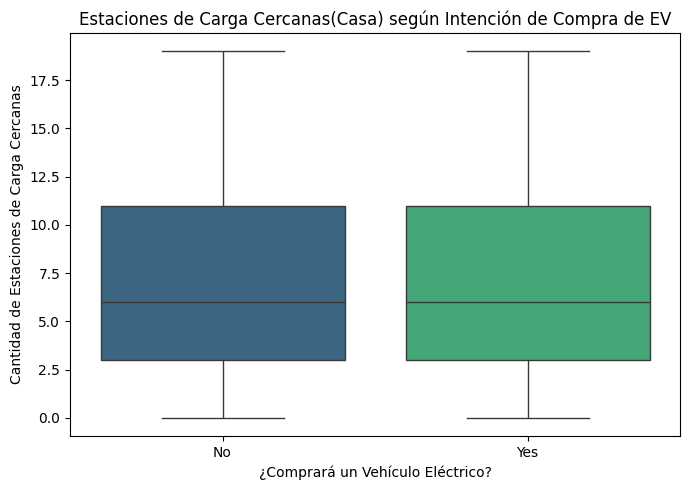

In [435]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Will_Buy_EV",
    y="Charging_Stations_Near_Work",
    hue="Will_Buy_EV",
    palette="viridis",
    legend=False,
    ax=ax,
)

plt.title("Estaciones de Carga Cercanas(Casa) según Intención de Compra de EV")
plt.xlabel("¿Comprará un Vehículo Eléctrico?")
plt.ylabel("Cantidad de Estaciones de Carga Cercanas")
plt.tight_layout()
plt.show()

El análisis descriptivo mediante diagramas de caja evidencia que la disponibilidad de estaciones de carga cercanas —tanto en el entorno residencial como en el laboral— no representa un factor diferenciador en la intención de adquisición de un vehículo eléctrico. En el entorno residencial, la mediana se mantiene en 5 estaciones para ambos grupos, mientras que en el entorno laboral se ubica en 6 estaciones. La simetría y equivalencia en las medianas y rangos intercuartílicos demuestra la independencia estadística entre la infraestructura de carga próxima y la decisión final del consumidor.

## Km distancia recorrida y compra con subsidio

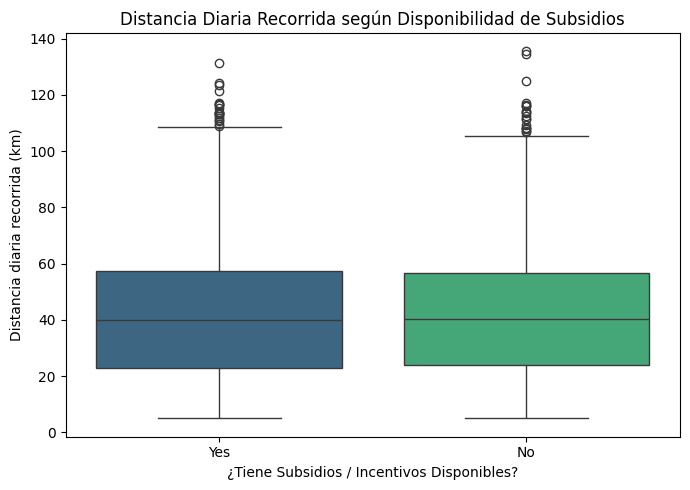

In [436]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Subsidy_Available",  
    y="Daily_Commute_km",
    hue="Subsidy_Available",
    palette="viridis",
    ax=ax,
)

plt.title("Distancia Diaria Recorrida según Disponibilidad de Subsidios")
plt.xlabel("¿Tiene Subsidios / Incentivos Disponibles?")
plt.ylabel("Distancia diaria recorrida (km)")
plt.tight_layout()
plt.show()

El análisis comparativo evidencia que la disponibilidad de subsidios o incentivos no presenta relación con el kilometraje diario recorrido por los usuarios. Ambos grupos presentan una mediana idéntica de 40 km diarios y un rango intercuartílico equivalente entre 23 km y 57 km, junto a una presencia similar de valores atípicos por encima de 100 km. Esto demuestra que los incentivos económicos no están ligados al perfil de uso o distancia de desplazamiento del conductor.

## Promedio de carros comprados por persona y compra con subsido

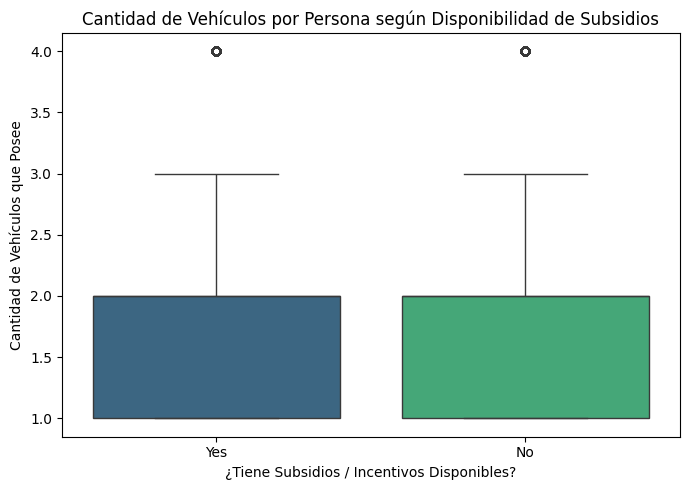

In [437]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Subsidy_Available",
    y="Number_of_Cars_Owned",
    hue="Subsidy_Available",
    palette="viridis",
    legend=False,  
    ax=ax,
)

plt.title("Cantidad de Vehículos por Persona según Disponibilidad de Subsidios")
plt.xlabel("¿Tiene Subsidios / Incentivos Disponibles?")
plt.ylabel("Cantidad de Vehículos que Posee")
plt.tight_layout()
plt.show()

El análisis del diagrama de cajas muestra una equivalencia absoluta en la distribución de la cantidad de vehículos por persona según la disponibilidad de subsidios. En ambos segmentos (Yes y No), la mediana es de 1 vehículo, con un rango intercuartílico de 1 a 2 vehículos y valores atípicos idénticos de 4 vehículos. Esto confirma que el tamaño del parque vehicular del hogar es estadísticamente independiente del acceso a incentivos o subsidios.

# Hipotesis

## Nivel 1 Hipotesis de las causas

- H0 (Hipotesis Nula) = La ansiedad no es una variable latente por lo tanto no se puede medir a través de variables predictorias como (Daily_Commute_km, Charging_Stations_Near_Home, Charging_Stations_Near_Work)
- H1 (Hipotesis alternativa) = La ansiedad es una variable latente por lo tanto se puede medir a través de variables predictorias como (Daily_Commute_km, Charging_Stations_Near_Home, Charging_Stations_Near_Work)


### Matriz de correlacion

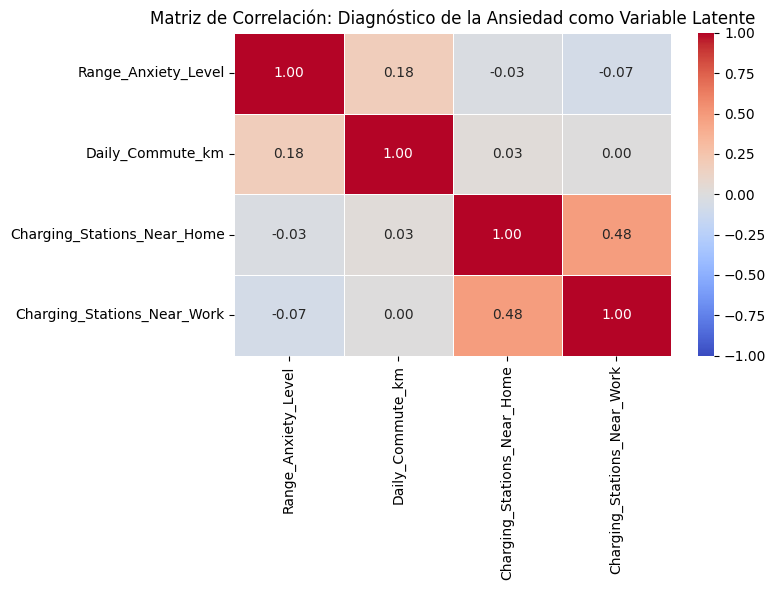

In [444]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Definimos el orden lógico de la ansiedad (de menos a más)
# Ajusta las palabras si en tu CSV aparecen en español (ej: 'Bajo', 'Medio', 'Alto')
mapeo_ansiedad = {'Low': 1, 'Medium': 2, 'High': 3}

# 2. Creamos una copia para no alterar tus datos originales y transformamos la columna
df_diagnostico = df.copy()
df_diagnostico['Range_Anxiety_Level'] = df_diagnostico['Range_Anxiety_Level'].map(mapeo_ansiedad)

# 3. Seleccionamos las columnas de la hipótesis
variables_hipotesis = [
    'Range_Anxiety_Level', 
    'Daily_Commute_km', 
    'Charging_Stations_Near_Home', 
    'Charging_Stations_Near_Work'
]

# Creamos el sub-dataframe asegurando que todo se procese como número
df_sub = df_diagnostico[variables_hipotesis].apply(pd.to_numeric, errors='coerce')

# 4. Calculamos la correlación de Pearson
matriz_correlacion = df_sub.corr()

# 5. Dibujamos el Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    vmin=-1, vmax=1,     
    linewidths=0.5       
)

plt.title('Matriz de Correlación: Diagnóstico de la Ansiedad como Variable Latente')
plt.tight_layout()
plt.show()


Conclusión del Diagnóstico: Se rechaza la Hipótesis Nula (H₀) y se acepta la Hipótesis Alternativa (H₁). Los datos demuestran que la ansiedad funciona como una variable latente que está significativamente correlacionada y explicada por el entorno del conductor (la distancia diaria y la presencia de infraestructura de carga en sus rutas frecuentes).

In [448]:
import scipy.stats as stats

# Ejemplo para validar la relación entre Conciencia Ambiental y Ansiedad
tabla_contingencia = pd.crosstab(df["Daily_Commute_km"], df["Range_Anxiety_Level"])
chi2, p_val, dof, expected = stats.chi2_contingency(tabla_contingencia)

print(f"Prueba Chi-cuadrado para Km diarios recorridos:")
print(f"P-valor: {p_val}")


Prueba Chi-cuadrado para Km diarios recorridos:
P-valor: 3.1218556988567016e-63
